In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'chain'
program = 'chain'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


            mean        std      median         q25         q75
0    -222.645069  96.500736 -193.901432 -250.790121 -150.866020
1    -173.247790  63.556416 -146.314681 -196.133376 -131.978865
2    -139.546030  23.081782 -131.687501 -144.805312 -127.991797
3    -122.068604   8.111232 -119.051063 -125.488028 -116.349636
4    -118.322032   5.316315 -116.038499 -121.293482 -114.899037
...          ...        ...         ...         ...         ...
1496  -71.302724   3.207448  -69.786811  -71.961740  -69.255513
1497  -71.302724   3.207448  -69.786811  -71.961740  -69.255513
1498  -71.302724   3.207448  -69.786811  -71.961740  -69.255513
1499  -71.301240   3.208645  -69.786811  -71.961740  -69.255513
1500  -71.301240   3.208645  -69.786811  -71.961740  -69.255513

[1501 rows x 5 columns]


In [3]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + likelihood_intervened
likelihood_base = likelihood_base + likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -7.423867262207755

Likelihood of baseline program: -9.561004692840122
Total likelihood of real program: -56.02425802363316
Total likelihood of baseline program: -118.28796939513782


In [4]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -68.70584610615609
Best program content:
Generation:
1500

Phenotype:
4
V1 = gm([8.6e0, +8.2e0, 4.3e0]);
V2 = +0.0e0 * -V1 * -9.4e0 - -V1 * +V1;
V2 = V2 + gm([0.7e1, -5.1e0, 0.8e1], [8.3e0, +3.4e0, 9.6e0], [0.9e0, +0.8e1, 9.3e0]);
V3 = -3.0e0;
V3 = V3 + gm([0.0e1, +9.9e0, 2.4e0], [0.0e0, +1.4e1, 1.5e0]);

Pre-processed Program
:T = gm([1.000000], [8.2], [4.3]);TEMP0 = 0 * T;TEMP1 = T * T;TEMP1 = 0 - TEMP1;P = TEMP0;P = P - TEMP1;P = P + gm([0.432099, 0.512346, 0.055556], [-5.1, 3.4, 8], [8, 9.6, 9.3]);F = 0;F = F - 3;F = F + gm([1.000000, 1.000000], [9.9, 14], [2.4, 1.5]);Genotype:
[18, 249, 369, 94, 61, 132, 264, 158, 186, 276, 260, 250, 278, 282, 62, 231, 404, 243, 8, 391, 195, 386, 239, 275, 182, 349, 465, 130, 430, 40, 378, 66, 63, 439, 237, 112, 277, 409, 394, 208, 269, 203, 234, 2, 71, 115, 326, 58, 469, 218, 10, 21, 312, 10, 267, 375, 170, 59, 415, 301, 66, 175, 300, 118, 415, 73, 55, 478, 383, 4, 420, 458, 213, 484, 190, 198, 119, 116, 282, 56, 188, 360, 9, 204

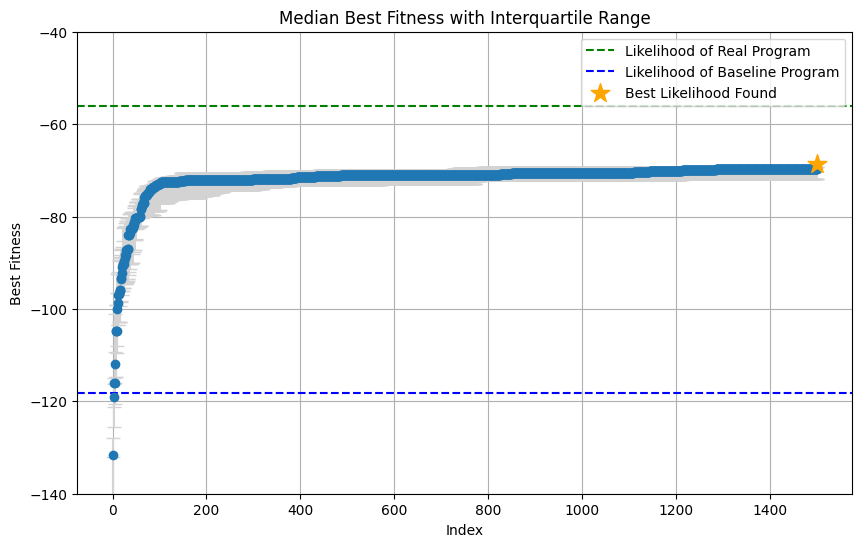

In [ ]:
# Plot results_df median with shaded interquartile range
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['median'], 'o-', label='Median Best Fitness')
plt.fill_between(
    results_df.index,
    results_df['q25'],
    results_df['q75'],
    color='lightgray',
    alpha=0.4,
    label='Interquartile Range (Q25-Q75)'
)
plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-140, -40)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()

In [40]:
no_int_ex_name = 'common_cause_no_interventions'

# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern_no_int = path.join('..', 'results', no_int_ex_name, '**', 'best.txt')
files_no_int = glob(pattern_no_int, recursive=True)
likelihoods_no_int = []
likelihoods_no_int_no_interventions = []
for file in files_no_int:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_int_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood_no_int = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        try:
            interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        except Exception as e:
            print(f'Error computing likelihood for intervention {var}={value}: {e}')
            interventional_likelihood = -1000000.0
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood_no_int += interventional_likelihood

    likelihoods_no_int.append(likelihood_no_int)
    likelihoods_no_int_no_interventions.append(likelihood_no_int_no_interventions)

likelihoods_no_int = [x + y for x, y in zip(likelihoods_no_int, likelihoods_no_int_no_interventions)]
print(f'Likelihoods of programs found without interventions: {likelihoods_no_int_no_interventions}')
print(f'Likelihoods of programs found interventions: {likelihoods_no_int}')

Likelihoods of programs found without interventions: [tensor(-6.0630), tensor(-6.6587), tensor(-6.4693), tensor(-6.7295), tensor(-5.3517), tensor(-6.5588), tensor(-5.8534), tensor(-6.6636), tensor(-7.3365), tensor(-6.0660), tensor(-6.0921), tensor(-6.0432)]
Likelihoods of programs found interventions: [tensor(-52.1508), tensor(-56.5156), tensor(-54.1537), tensor(-57.3124), tensor(-65.2394), tensor(-56.5966), tensor(-60.7960), tensor(-57.1376), tensor(-73.2544), tensor(-64.1739), tensor(-74.1554), tensor(-71.3333)]


In [41]:
import torch
ex_name = 'common_cause_no_if'

# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern = path.join('..', 'results', ex_name, '**', 'best.txt')
files = glob(pattern, recursive=True)
likelihoods = []
likelihoods_no_interventions = []
for file in files:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    likelihoods_no_interventions.append(likelihood_no_interventions)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood += interventional_likelihood
        #print(f'Likelihood after intervention {var}={value}: {likelihood}')

    likelihoods.append(likelihood)
print(len(likelihoods))
#sum the two lists element-wise
likelihoods = [x + y for x, y in zip(likelihoods, likelihoods_no_interventions)]
print(f'Likelihoods of programs found interventions: {likelihoods}')
print(f'Likelihoods of programs found without interventions: {likelihoods_no_interventions}')

print(len(likelihoods))
print(len(likelihoods_no_interventions))

10
Likelihoods of programs found interventions: [tensor(-59.6050), tensor(-53.8842), tensor(-55.1599), tensor(-53.5372), tensor(-56.5863), tensor(-46.6422), tensor(-53.2217), tensor(-58.6023), tensor(-50.6768), tensor(-54.1499)]
Likelihoods of programs found without interventions: [tensor(-7.3785), tensor(-6.6677), tensor(-6.9404), tensor(-6.5615), tensor(-7.0140), tensor(-5.3502), tensor(-6.5666), tensor(-7.0018), tensor(-6.1994), tensor(-6.6269)]
10
10


In [42]:
import torch
print("Likelihood:")
print(torch.mean(torch.tensor(likelihoods_no_interventions)))
print("Interventional Likelihood")
print(torch.mean(torch.tensor(likelihoods)))
print("Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int_no_interventions)))
print("Interventional Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int)))
likelihoods_no_int_filtered = [x for x in likelihoods_no_int if x > -10000.0]
print(likelihoods_no_int_filtered)

Likelihood:
tensor(-6.6307)
Interventional Likelihood
tensor(-54.2065)
Likelihood without interventions:
tensor(-6.3238)
Interventional Likelihood without interventions:
tensor(-61.9016)
[tensor(-52.1508), tensor(-56.5156), tensor(-54.1537), tensor(-57.3124), tensor(-65.2394), tensor(-56.5966), tensor(-60.7960), tensor(-57.1376), tensor(-73.2544), tensor(-64.1739), tensor(-74.1554), tensor(-71.3333)]


/tmp/ipykernel_10069/1934761811.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])


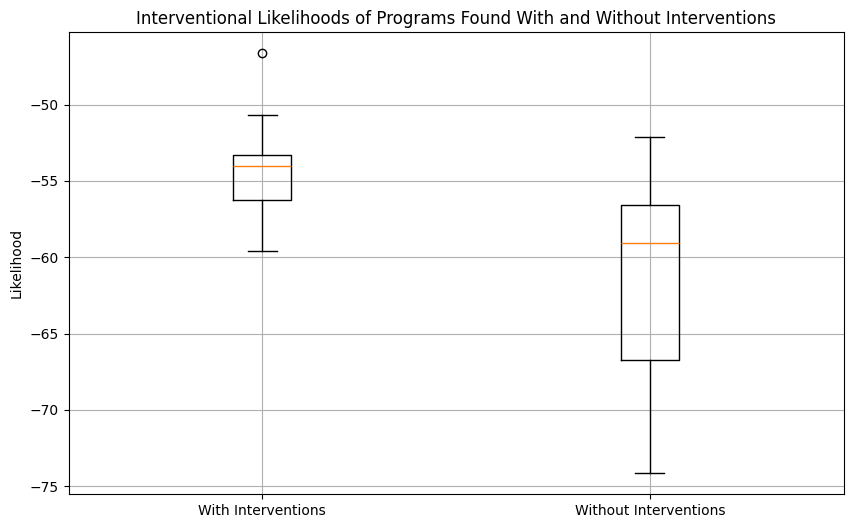

In [44]:
#create a boxplot with mean and variance of likelihoods_no_interventions and likelihoods_no_int_no_interventions
plt.figure(figsize=(10, 6))

plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])
plt.title('Interventional Likelihoods of Programs Found With and Without Interventions')

#plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])
#plt.title('Likelihoods of Programs Found With and Without Interventions')

plt.ylabel('Likelihood')
plt.grid()
plt.show()

Number of evolutionary steps aggregated: 1502


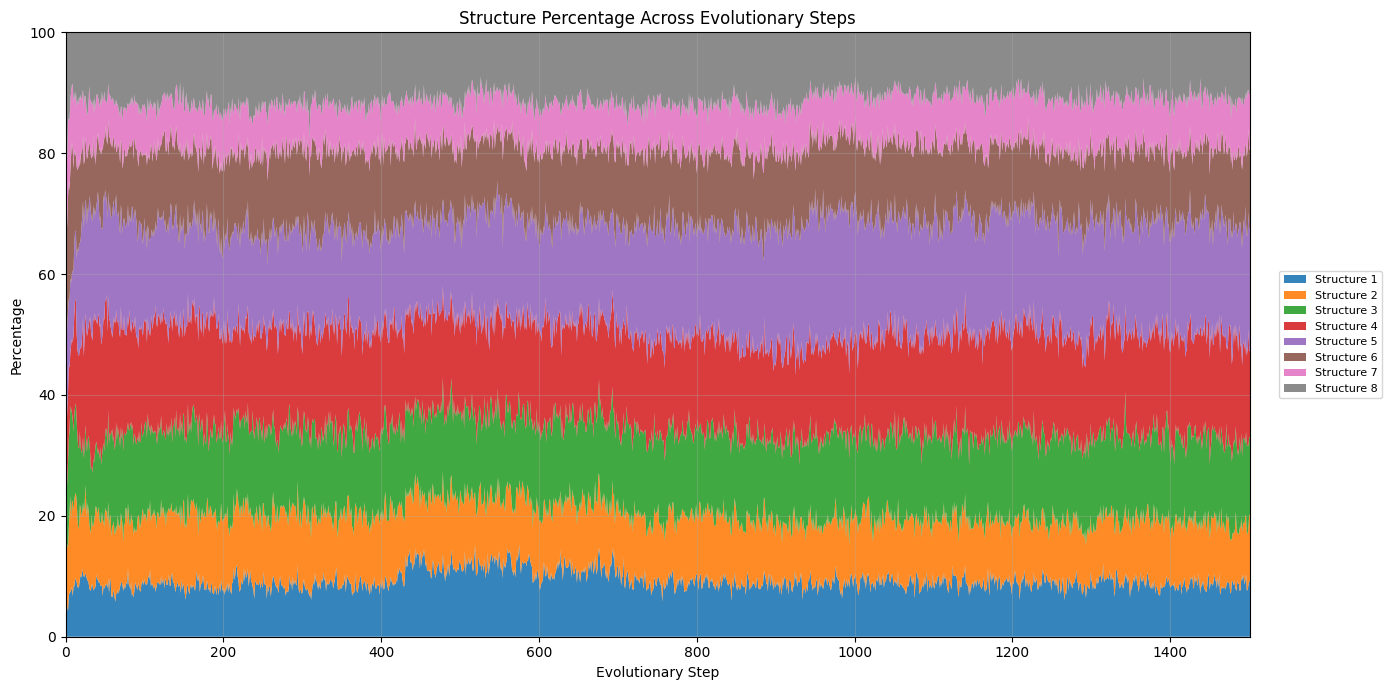

In [49]:
from collections import Counter
import re

ex_name = 'common_cause_no_if'
pattern = path.join('..', 'results', ex_name, '**', 'structure.csv')
files = glob(pattern, recursive=True)

# structure_counts_aggregated[step] = Counter({structure_index: total_count_across_all_runs})
structure_counts_aggregated = []

for file in files:
    df = pd.read_csv(file, header=None)

    for step_idx, row in df.iterrows():
        while len(structure_counts_aggregated) <= step_idx:
            structure_counts_aggregated.append(Counter())

        row_text = str(row.iloc[0]).strip()
        if row_text == '' or row_text.lower() == 'nan':
            continue

        indices = [idx for idx in re.split(r'\s+', row_text) if idx != '']
        structure_counts_aggregated[step_idx].update(indices)

print(f'Number of evolutionary steps aggregated: {len(structure_counts_aggregated)}')

# Build a consistent list of all structures that appeared
all_structures = sorted({s for c in structure_counts_aggregated for s in c.keys()}, key=lambda x: int(x))
n_steps = len(structure_counts_aggregated)
x = np.arange(n_steps)

# percentages[i, t] = percentage of structure i at step t
percentages = np.zeros((len(all_structures), n_steps), dtype=float)

for t, counter in enumerate(structure_counts_aggregated):
    total = sum(counter.values())
    if total == 0:
        continue
    for i, structure in enumerate(all_structures):
        percentages[i, t] = 100.0 * counter.get(structure, 0) / total

# Stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(x, *percentages, labels=[f'Structure {s}' for s in all_structures], alpha=0.9)
plt.title('Structure Percentage Across Evolutionary Steps')
plt.xlabel('Evolutionary Step')
plt.ylabel('Percentage')
plt.xlim(0, n_steps - 1)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
from fitness.minimise_causal_arrows import count_causal_arrows, structure_to_id, structure_to_id_undirected, perm_to_mapping
p = """
V1 = gm([1.0e0, +8.2e0, 0.2e0], [5.6e1, +4.9e0, 1.5e0], [0.0e0, -6.8e1, 6.4e1]);
V2 = -8.7e0 ;
V2 = V2 + uniform([+7.2e0, 2.1e1], 2);
V3 =  +2.0e0;
V3 = V3 + gm([7.3e0, +8.1e0, 2.0e0]);
"""
perm = 6

data_var_list, scm = dgp.get_vars('common_cause')
v_to_data = perm_to_mapping(perm, data_var_list)
print(v_to_data)
num, edges =count_causal_arrows(p)

#structure_id = structure_to_id(edges)
structure_id = structure_to_id_undirected(edges, perm, data_var_list)
print(structure_id)

{'V1': 'T', 'V2': 'C', 'V3': 'F'}
1
